<a href="https://colab.research.google.com/github/taraswoj/pybibx/blob/main/pyBibX_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
############################################################################

# Created by: Prof. Valdecy Pereira, D.Sc.
# UFF - Universidade Federal Fluminense (Brazil)
# email:  valdecy.pereira@gmail.com
# pyBibX - A Bibliometric and Scientometric Library
# Example - Scopus + WOS

# Citation:
# PEREIRA, V.; BASILIO, M.P.; SANTOS, C.H.T. (2025). PyBibX: A Python Library for Bibliometric and
# Scientometric Analysis Powered with Artificial Intelligence Tools. Data Technologies and Applications.
# Vol. 59, Iss. 2, pp. 302-337. doi: https://doi.org/10.1108/DTA-08-2023-0461

############################################################################

In [ ]:
!pip install pybibx
!pip install tabulate

In [ ]:
# Dowload .bib files
!wget https://github.com/Valdecy/pyBibX/raw/main/assets/bibs/scopus.bib
!wget https://github.com/Valdecy/pyBibX/raw/main/assets/bibs/wos.bib

In [ ]:
# Required Libraries
import numpy as np
import pandas as pd
import textwrap

from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

# Load Dataset
---
In this section, we will load and inspect the dataset.

In [ ]:
# Load .bib
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus.bib'
database  = 'scopus'
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 261 Documents were Found ( 263 Documents and 2 Duplicates )

Article = 179
Article in Press = 1
Book Chapter = 12
Conference Paper = 64
Conference Review = 3
Review = 2


In [ ]:
# Merge Database
file_name_ = 'wos.bib'
database_  = 'wos'
bibfile.merge_database(file_bib = file_name_, db = database_, del_duplicated = True)

############################################################################

Original Database

A Total of 261 Documents were Found ( 263 Documents and 2 Duplicates )

Article = 179
Article in Press = 1
Book Chapter = 12
Conference Paper = 64
Conference Review = 3
Review = 2

############################################################################

Added Database

A Total of 235 Documents were Found ( 236 Documents and 1 Duplicates )

Article = 173
Article in Press = 3
Proceedings Paper = 56
Review = 3

############################################################################

Merging Information:

A Total of 322 Documents were Found ( 61 New Documents from the Added Database )

Article  =  222
Article in Press  =  1
Book Chapter  =  12
Conference Paper  =  64
Conference Review  =  3
Proceedings Paper  =  16
Review  =  4

############################################################################


In [ ]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,95.34%,307
1,Abstracts,99.69%,321
2,Affiliation,100.00%,322
3,Author(s),98.14%,316
4,DOI,87.58%,282
5,Keywords - Authors,88.20%,284
6,Keywords - Plus,72.05%,232
7,References,97.52%,314
8,Year,100.00%,322


In [ ]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,1998-2022
1,Total Number of Countries,37
2,Total Number of Institutions,369
3,Total Number of Sources,179
4,Total Number of References,10328
5,Total Number of Languages,7
6,--croatian (# of docs),1
7,--english (# of docs),309
8,--english; lithuanian (# of docs),1
9,--french (# of docs),3


In [ ]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+---------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

,ID,Document
0,0,"Figueira, J.R. and Greco, S. and Roy, B. (2022..."
1,1,"de Araújo, M.C.B. and Alencar, L.H. and de Mir..."
2,2,"Viana, F.F.C.L. and Alencar, M.H. and Ferreira..."
3,3,"Ahmed, U. and Carpitella, S. and Certa, A. (20..."
4,4,"Rocha, A. and Costa, A.S. and Figueira, J.R. a..."
...,...,...
317,317,"Doumpos, M and Zopounidis, C (2004). A multicr..."
318,318,"Doumpos, M and Zopounidis, C (2004). Developin..."
319,319,"Damart, S and Mousseau, V and Sommerlatt, I (2..."
320,320,"Zopounidis, C and Doumpos, M (2002). Multicrit..."


In [ ]:
# Check Docs IDs per Type
data_table.DataTable(bibfile.id_doc_types(), num_rows_per_page = 15)

,Document Types,IDs
0,Article,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Article in Press,[92]
2,Book Chapter,"[58, 84, 108, 129, 130, 131, 132, 133, 134, 16..."
3,Conference Paper,"[14, 18, 19, 22, 33, 36, 38, 42, 44, 60, 61, 6..."
4,Conference Review,"[81, 100, 206]"
5,Proceedings Paper,"[275, 278, 283, 288, 295, 296, 298, 299, 300, ..."
6,Review,"[142, 174, 261, 320]"


In [ ]:
# Check Authors IDs
data_table.DataTable(bibfile.table_id_aut, num_rows_per_page = 15)

,ID,Author
0,a_0,"abed, m."
1,a_1,"abed, mourad"
2,a_2,"abi-zeid, i."
3,a_3,"achki, s."
4,a_4,"addi, a.-m."
...,...,...
624,a_624,"zopounidis, c."
625,a_625,"özpeynirci, o."
626,a_626,"özpeynirci, s.b."
627,a_627,"öztürk, m."


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_a = bibfile.profiling_author(label_name = None, label_id = 'a_8', topn = 5)
print(tabulate(profile_a, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                │
╞════════════════════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ ahmed, u.                                                                                                            │
├────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Affiliation        │ ['university of palermo', 'università degli studi di palermo']                                                       │
├────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Coun

In [ ]:
# These indices are local (considers only the .bib scope)
# H-index measures their academic impact by identifying the number of papers (h) that have each received at least h citations
# E-Index quatifies excess citations within the H-core revealing "hidden" impact beyond the H-index threshold.
# The G-Index emphasizes highly cited work, making it sensitive to breakthrough publications.
# The M-Index contextualizes the H-index by normalizing it over the researcher’s career duration
aut_m = bibfile.m_index(2022)
df_idx = {
    'Author': bibfile.u_aut,
    'H-index': bibfile.aut_h,
    'E-Index': bibfile.aut_e,
    'G-Index': bibfile.aut_g,
    'M-Index': aut_m
}

df_idx = pd.DataFrame(df_idx)
df_idx

,Author,H-index,E-Index,G-Index,M-Index
0,"abed, m.",1,0.000000,1,0.166667
1,"abed, mourad",0,0.000000,0,0.000000
2,"abi-zeid, i.",2,3.872983,4,0.200000
3,"achki, s.",0,0.000000,0,0.000000
4,"addi, a.-m.",1,0.000000,1,0.142857
...,...,...,...,...,...
624,"zopounidis, c.",4,11.180340,4,0.190476
625,"özpeynirci, o.",1,5.567764,1,0.071429
626,"özpeynirci, s.b.",1,5.567764,1,0.071429
627,"öztürk, m.",1,1.000000,1,0.125000


In [ ]:
# Check Sources IDs
data_table.DataTable(bibfile.table_id_jou, num_rows_per_page = 15)

,ID,Source
0,j_0,eur j oper res
1,j_1,eur. j. oper. res.
2,j_2,omega
3,j_3,lect. notes comput. sci.
4,j_4,journal of multi-criteria decision analysis
...,...,...
174,j_174,appl. math. model.
175,j_175,adv. soft comput.
176,j_176,"adv. sci., technol. eng. syst."
177,j_177,adv. eng. inf.


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_j = bibfile.profiling_journal(label_name = None, label_id = 'j_1', topn = 5)
print(tabulate(profile_j, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                                                                               │
╞════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ eur. j. oper. res.                                                                                                                                                                  │
├────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# Check Institutions IDs
data_table.DataTable(bibfile.table_id_uni, num_rows_per_page = 15)

,ID,Institution
0,i_0,school of technology and management
1,i_1,università degli studi della tuscia
2,i_2,meccanica/universitá degli studi di palermo
3,i_3,faculté polytechnique de mons
4,i_4,middle east technical university
...,...,...
364,i_364,universidade estadual do norte fluminense
365,i_365,center for the sustainable development of semi...
366,i_366,university of science and technology beijing
367,i_367,university of belgrade – faculty of economicss...


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_i = bibfile.profiling_affiliation(label_name = None, label_id = 'i_9', topn = 5)
print(tabulate(profile_i, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                                 │
╞════════════════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Entity             │ 2 av. madeleine bonnaud parc d'activites point rencontre                                                              │
├────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Authors            │ ['vuillet, m.']                                                                                                       │
├────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤

In [ ]:
# Check Countries IDs
data_table.DataTable(bibfile.table_id_ctr, num_rows_per_page = 15)

,ID,Country
0,c_0,Brazil
1,c_1,Austria
2,c_2,Poland
3,c_3,Germany
4,c_4,Denmark
5,c_5,India
6,c_6,Croatia
7,c_7,Lebanon
8,c_8,Netherlands
9,c_9,Spain


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_c = bibfile.profiling_country(label_name = None, label_id = 'c_0', topn = 5)
print(tabulate(profile_c, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
# Check Authors Keywords IDs
data_table.DataTable(bibfile.table_id_kwa, num_rows_per_page = 15)

,ID,KWA
0,k_0,electre tri
1,k_1,sorting
2,k_2,multiple criteria analysis
3,k_3,multiple criteria sorting
4,k_4,multicriteria
...,...,...
811,k_811,abc classification
812,k_812,68n99
813,k_813,2-rank
814,k_814,(s) multiple criteria analysis


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_k = bibfile.profiling_keyword(label_name = None, label_id = 'k_0', topn = 5)
print(tabulate(profile_k, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
# Check Keywords Plus IDs
data_table.DataTable(bibfile.table_id_kwp, num_rows_per_page = 15)

,ID,KWP
0,p_0,electre tri
1,p_1,decision making
2,p_2,decision support systems
3,p_3,electre
4,p_4,multicriteria analysis
...,...,...
1469,p_1469,accident
1470,p_1470,absolute performance
1471,p_1471,abc analysis
1472,p_1472,abandoned mine


In [ ]:
# Profile
# Arguments: label_name = Entity name;
#            label_id   = Entity ID;
#            topn       = Top N relations;
profile_p = bibfile.profiling_keyword_plus(label_name = None, label_id = 'p_0', topn = 5)
print(tabulate(profile_p, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric             │ Value                                                                                                      

In [ ]:
# Check Reference IDs (If References are Given)
df = pd.DataFrame({'Reference': bibfile.u_ref, 'Reference ID': bibfile.u_ref_id})
data_table.DataTable(df, num_rows_per_page = 15)

,Reference,Reference ID
0,'Une Approche Originale Par L'analyse Multicri...,r_0
1,"(1972) Handbook of Fundamentals, p. 688. , ASH...",r_1
2,"(1977) Cadre Pour L'évaluation Des Terres, 32,...",r_2
3,"(1977), p. 64. , FAO, Cadre pour l'évaluation ...",r_3
4,(1985) Attributes of Materials Management Syst...,r_4
...,...,...
10323,"Şahin, M., (2018) Design and Development of th...",r_10323
10324,"Şahin, M., Keskin, S., Özgür, A., Yurdugül, H....",r_10324
10325,"Şebnem, S., Balaman, Y., A novel outranking ba...",r_10325
10326,"Šimić, G., Gašević, D., Devedžić, V., (2004) S...",r_10326


In [ ]:
# Profile
# Arguments: label_id   = Entity ID;
#            topn       = Top N relations;
profile_r = bibfile.profiling_reference(label_id = 'r_5', topn = 5)
print(tabulate(profile_r, headers = ["Metric", "Value"], tablefmt = "fancy_grid"))

╒═════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Metric          │ Value                                                                                                                                                                                                                                             

# Exploratory Data Analysis
---
In this section, we will perform EDA

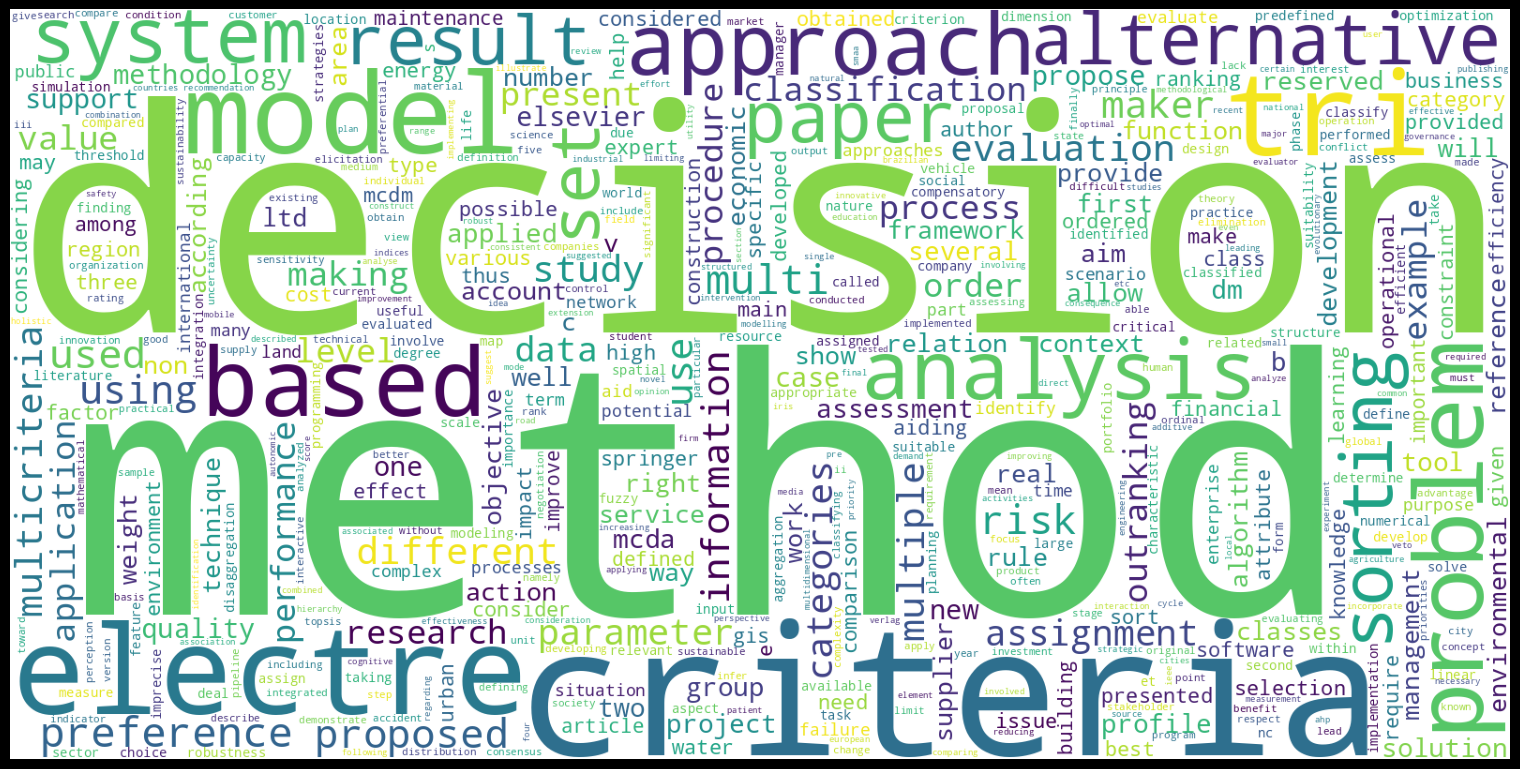

In [ ]:
# WordCloud from the Abstracts, Title, Authors Keywords or Keywords Plus
# Arguments: entry             = 'abs', 'title', 'kwa', or 'kwp'
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = 500, rmv_custom_words = [])

In [ ]:
# Check Table
num_columns = 5
data_wd     = bibfile.ask_gpt_wd
items       = list(data_wd.items())

field_names = []
for i in range(num_columns):
    field_names.append(f"Word {i + 1}")
    field_names.append(f"Importance {i + 1}")

table = PrettyTable()
table.field_names = field_names

for i in range(0, len(items), num_columns):
    row = []
    for j in range(num_columns):
        if i + j < len(items):
            word, importance = items[i + j]
            row.extend([word, round(importance, 4)])
        else:
            row.extend(["", ""])
    table.add_row(row)

# Print the table
print(table)

+----------------+--------------+----------------+--------------+----------------+--------------+------------------+--------------+----------------+--------------+
|     Word 1     | Importance 1 |     Word 2     | Importance 2 |     Word 3     | Importance 3 |      Word 4      | Importance 4 |     Word 5     | Importance 5 |
+----------------+--------------+----------------+--------------+----------------+--------------+------------------+--------------+----------------+--------------+
|     method     |     1.0      |    decision    |    0.9207    |    criteria    |    0.6942    |     electre      |    0.6877    |      tri       |    0.6181    |
|     model      |    0.5809    |    problem     |    0.4013    |     based      |    0.3981    |     approach     |     0.39     |    analysis    |    0.3673    |
|     system     |    0.3188    |  alternative   |    0.3139    |     paper      |    0.3107    |     sorting      |    0.3074    |     result     |    0.2864    |
|      set      

In [ ]:
# N-Grams
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry      = 'abs', 'title', 'kwa', or 'kwp'
#            n_grams    = An integer with size n (representing the most common groups of words with size n)
#            stop_words = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                         'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                         'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                          'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus
#             wordsn           = Number of N-Grams
bibfile.get_top_ngrams(view = 'notebook', entry = 'kwp', ngrams = 3, stop_words = [], rmv_custom_words = [], wordsn = 15)

In [ ]:
# Check Table
data_ng = bibfile.ask_gpt_ng
data_table.DataTable(data_ng, num_rows_per_page = 15)

,Word,Freq
0,decision support systems,60
1,multi criteria decision,48
2,decision making decision,24
3,multiple criteria decision,22
4,criteria decision analysis,19
5,criteria decision making,18
6,making decision support,18
7,multi criteria analysis,16
8,criteria decision aiding,16
9,geographic information systems,16


In [ ]:
# Documents Projection based on Words. (An interactive plot). It returns the Projection (each document coordinate) and the Labels (each document cluster)
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            custom_label      = A list of custom labels for each document. The user can define each document cluster;
#            custom_projection = A list of custom coordinates for each document. The user can define each document coordinate;
#            n_components      = Number of Dimensions;
#            n_clusters        = Only relevant if  cluster_method = 'kmeans'.Number of Clusters.;
#            node_labels       = If True, labels appear in nodes;
#            node_size         = Node size;
#            node_font_size    = Node font size;
#            tf_idf            = True or False (True -> The Cluster Algorithm will use the DTM to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            embeddings        = True or False (True -> The Cluster Algorithm will use the Word Embeddings to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            model             = Only relevant if 'embeddings = True'. Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased';
#            method            = 'tsvd' or 'umap' ('tsvd' -> Truncated SVD projection method is used. 'umap' -> UMAP projection method is used);
#            showlegend        = If True, shows legend;
#            cluster_method    = 'kmeans' or 'hdbscan';
#            min_size          = Only relevant if  cluster_method = 'hdbscan'. Minimum number of elements in a Cluster;
#            max_size          = Only relevant if  cluster_method = 'hdbscan'. Maximum number of elements in a Cluster
projection, labels = bibfile.docs_projection(view              = 'notebook',
                                             corpus_type       = 'abs',
                                             stop_words        = ['en'],
                                             rmv_custom_words  = [],
                                             custom_label      = [],
                                             custom_projection = [],
                                             n_components      = 2,
                                             n_clusters        = 5,
                                             node_labels       = True,
                                             node_size         = 20,
                                             node_font_size    = 10,
                                             tf_idf            = False,
                                             embeddings        = False,
                                             model             = 'allenai/scibert_scivocab_uncased',
                                             method            = 'umap',
                                             showlegend        = True,
                                             cluster_method    = 'kmeans',
                                             min_size          = 5,
                                             max_size          = 50
                                             )

In [ ]:
# Check Table
data_pr = pd.DataFrame(np.hstack([projection, labels.reshape(-1,1)]))
data_table.DataTable(data_pr, num_rows_per_page = 15)

,0,1,2
0,8.191989,3.505559,1.0
1,4.090523,4.428333,4.0
2,4.589939,3.561324,4.0
3,7.664089,6.499958,2.0
4,6.108918,5.793664,2.0
...,...,...,...
317,9.198402,3.743632,3.0
318,9.344827,4.624022,3.0
319,4.898416,5.060323,0.0
320,6.921594,4.997763,2.0


In [ ]:
# Check Articles per Cluster
cluster      = 0
idx_articles = [i for i in range(0, labels.shape[0]) if labels[i] == cluster]
print(*idx_articles, sep = ', ')

6, 9, 25, 28, 29, 32, 40, 41, 43, 48, 58, 60, 63, 66, 71, 75, 76, 78, 79, 82, 88, 91, 94, 99, 105, 116, 120, 132, 140, 143, 152, 162, 168, 169, 171, 175, 176, 190, 212, 215, 216, 218, 219, 224, 232, 233, 236, 239, 246, 255, 266, 274, 275, 319


In [ ]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            key               = 'abs', 'title', 'jou, 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            topn              = Total number entities;
#            txt_font_size     = Font size of the text inside the bins;
#            start             = Start Year; -1 = all years
#            end               = End Year;   -1 = all years
bibfile.plot_evolution_year(view             = 'notebook',
                            stop_words       = [],
                            rmv_custom_words = [],
                            key              = 'kwa',
                            topn             = 10,
                            txt_font_size    = 12,
                            start            = 2010,
                            end              = 2021)

In [ ]:
# View Table
data_ep = bibfile.ask_gpt_ep
print(textwrap.fill(data_ep, 150))

 2010: electre tri (5), sorting (2), adaptive algorithms (2), handling preferences (2), electre tri-c (1), multiple criteria decision aiding (1),
multi criteria decision making (1), constructive approach (1), business process management (1), trustworthy software (1) 2011: multicriteria decision
aiding (2), sorting (2), preference elicitation (2), infertility (1), nsga-ii (1), multilateral environmental agreements (1), multicriteria assignment
(1), military staff (1), linear discriminant analysis (1), learning methods (1) 2012: electre tri (6), decision support (3), multiple criteria sorting
(2), multicriteria (2), outranking methods (2), multicriteria analysis (2), performance (2), mental disabilities (1), heuristic tree-search strategy
(1), information fusion (1) 2013: electre tri (4), multicriteria decision aid (2), sustainable development (2), evolutionary algorithms (2), multiple
criteria sorting (2), storage location assignment (1), stock management policies (1), riparian zone (1)

In [ ]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn              = Most frequent n words
#            custom            = Plot specific words
bibfile.plot_evolution_year_complement(data_ep, view = 'notebook', topn = 10, custom = [])

In [ ]:
# Sankey Diagram (An interactive plot)
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['aut', 'cout', 'lan'], topn = [3, 5], rmv_unknowns = True)

# PS: The white bars can be dragged

In [ ]:
# View Table
data_sk = bibfile.ask_gpt_sk
data_table.DataTable(data_sk, num_rows_per_page = 15)

,Node From,Node To,Connection Weigth
0,"mousseau, v.",France,15
1,"mousseau, v.",Portugal,4
2,"mousseau, v.",Belgium,1
3,"mousseau, v.",Turkey,1
4,"mousseau, v.",United States of America,1
5,"figueira, j.r.",Portugal,13
6,"figueira, j.r.",Mexico,2
7,"figueira, j.r.",France,2
8,"figueira, j.r.",Greece,1
9,"dias, l.c.",Portugal,16


In [ ]:
# Plot Count Y per X (An interactive bar chart)
# Arguments:
#   view          : Determines where the plot will be rendered. 'browser'  -> Plots in your preferred browser window. 'notebook' -> (if supported) Plots within your notebook environment.
#   rmv_unknowns  : Boolean flag to handle unknown entries. True  -> Removes any relationships containing unknown values.
#   x             : The key (column) to use for the X-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'cout'.
#   y             : The key (column) to use for the Y-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'aut'.
#   topn_x        : Maximum number of top X categories (based on total counts) to display. Default is 5.
#   topn_y        : Maximum number of top Y entries (per X category) to display. Default is 5.
#   text_font_size: Font size for the text labels displayed inside the bars. Default is 12.
#   x_angle       : Angle (in degrees) for the X-axis tick labels. Default is -90 (rotating labels vertically).
bibfile.plot_count_y_per_x(view = 'notebook', rmv_unknowns = True, x = 'cout', y = 'aut', topn_x = 5, topn_y = 5, text_font_size = 12, x_angle = -90)

In [ ]:
# View Table
data_table.DataTable(bibfile.top_y_x, num_rows_per_page = 15)

,Count,X (Countries),Y (Authors)
62,9,Brazil,"costa, h.g."
9,8,Brazil,"de almeida, a.t."
21,6,Brazil,"trojan, f."
64,4,Brazil,"pereira, v."
78,4,Brazil,"morais, d.c."
129,15,France,"mousseau, v."
2,5,France,"roy, b."
54,5,France,"bouyssou, d."
402,5,France,"cailloux, o."
55,4,France,"marchant, t."


In [ ]:
# Plot Heatmap Y per X (An interactive bar chart)
# Arguments:
#   view          : Determines where the plot will be rendered. 'browser'  -> Plots in your preferred browser window. 'notebook' -> (if supported) Plots within your notebook environment.
#   rmv_unknowns  : Boolean flag to handle unknown entries. True  -> Removes any relationships containing unknown values.
#   x             : The key (column) to use for the X-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'cout'.
#   y             : The key (column) to use for the Y-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'aut'.
#   topn_x        : Maximum number of top X categories (based on total counts) to display. Default is 5.
#   topn_y        : Maximum number of top Y entries (per X category) to display. Default is 5.
#   element_x     : Custom list of elements in X-axis
#   element_y     : Custom list of elements in Y-axis
bibfile.plot_heatmap_y_per_x(x = 'kwa', y = 'aut', topn_x = 15, topn_y = 5, element_x = [], element_y = [], rmv_unknowns = True, view = "notebook")

In [ ]:
# View Table
data_table.DataTable(bibfile.heat_y_x, num_rows_per_page = 15)

,electre tri,multiple criteria analysis,sorting,electre tri-c,multiple criteria decision aiding,mcda,multiple criteria sorting,multicriteria,decision support,classification,electre-tri,electre tri-nc,decision analysis,energy efficiency,electre
"figueira, j.r.",[221],"[0, 65, 86, 7]","[186, 203, 86]","[203, 140, 199]","[68, 199, 203, 140, 186, 28]",[221],[],[90],"[65, 203, 140, 86, 186]",[],[],"[65, 4, 68, 186, 25, 90, 28]",[4],[25],[]
"dias, l.c.","[248, 257, 168, 137, 212, 120, 153]","[168, 237]",[248],[],[],[74],[],[74],[],[248],[],[],[],[224],"[237, 223]"
"mousseau, v.","[256, 245, 248, 250, 156]","[237, 178, 242, 245, 249]","[248, 193]",[],[],[],"[220, 156]",[],[],"[248, 47]",[],[],[],[],"[242, 237]"
"antunes, c.h.","[164, 167, 202, 212, 182, 126]",[],[],[],[],[74],[],[74],[],[],[],[],[],"[224, 99]",[]
"roy, b.",[232],"[0, 86]","[186, 203, 86]","[203, 140, 199]","[186, 203, 140, 199]",[],[],[],"[186, 203, 140, 86]",[],[],[186],[],[],[]


In [ ]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 20)

In [ ]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 20)

In [ ]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,1998,1999,2000,2001,2002,2003,2004,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
"mousseau, v.",1.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
"figueira, j.r.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2.0,1.0,3.0,3.0,3.0,1.0
"dias, l.c.",0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,...,1.0,3.0,2.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0
"antunes, c.h.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
"costa, h.g.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
"roy, b.",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
"de almeida, a.t.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0
"pirlot, m.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
"kadzinski, milosz",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
"certa, a.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,0.0


In [ ]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [ ]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,All Years
france,2,0,7,2,6,2,4,0,0,11,...,12,12,6,7,11,11,6,4,1,157
brazil,0,0,0,0,0,0,0,0,1,4,...,18,6,10,16,20,18,18,18,3,149
portugal,0,2,2,3,3,4,2,0,2,3,...,14,11,3,14,9,17,5,13,1,147
italy,0,0,0,0,0,0,0,0,0,2,...,11,2,12,8,13,10,6,5,1,78
greece,0,0,0,0,4,8,2,0,0,4,...,3,0,0,3,0,2,5,0,0,50
poland,0,0,1,0,0,0,0,0,0,1,...,0,4,7,5,9,0,4,5,0,40
spain,0,0,0,0,0,0,0,0,0,4,...,6,3,6,0,0,0,1,7,0,39
china,0,0,0,0,0,0,0,0,0,0,...,0,2,3,1,3,5,10,6,0,37
mexico,0,0,0,0,0,0,0,0,0,0,...,0,5,3,8,3,6,2,1,0,33
belgium,0,0,0,2,0,0,0,0,0,0,...,3,3,3,4,0,1,0,1,0,24


In [ ]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 20)

In [ ]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,1998,1999,2000,2002,2003,2004,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
universidade de lisboa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,4.0,3.0,3.0
university of coimbra,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,...,1.0,2.0,2.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0
autonomous univ sinaloa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
xi an jiao tong univ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
poznan univ tech,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0
rey juan carlos university,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
national technical university of athens,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
università degli studi di palermo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,2.0
federal university of pernambuco,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
universidade federal fluminense,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0


In [ ]:
# Sources Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each source (journal)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.source_productivity(view = 'notebook', topn = 20)

In [ ]:
# View Table
data_sp = bibfile.ask_gpt_sp
data_table.DataTable(data_sp, num_rows_per_page = 15)

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
eur j oper res,0.0,1.0,1.0,1.0,2.0,2.0,0.0,1.0,3.0,3.0,...,0.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
eur. j. oper. res.,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,...,0.0,0.0,2.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0
omega,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,2.0,1.0,1.0,0.0
journal of multi-criteria decision analysis,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
lect. notes comput. sci.,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ann. oper. res.,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
int. trans. oper. res.,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0
pesqui. oper.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
comp. oper. res.,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
comput ind eng,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0


In [ ]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'apd', topn = 20)

In [ ]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Documents,Authors
0,"mousseau, v.",22
1,"figueira, j.r.",18
2,"dias, l.c.",17
3,"antunes, c.h.",10
4,"costa, h.g.",9
5,"roy, b.",8
6,"de almeida, a.t.",8
7,"pirlot, m.",7
8,"kadzinski, milosz",7
9,"certa, a.",7


In [ ]:
# Plot Top References
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn       = Specifies the number of top references (by citation count) to display in the plot;
#            font_size  = Controls the font size of the legend in the plot;
#            use_ref_id = Chooses between using reference names or reference IDs when processing and plotting data;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year.
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
bibfile.plot_top_refs(view = 'notebook', topn = 10, font_size = 10, use_ref_id = False, date_start = None, date_end = None)

In [ ]:
# Check Top References
data_table.DataTable(bibfile.top_refs, num_rows_per_page = 15)

# PS: Optionally, use 'bibfile.merge_reference(get = [], replace_for = 'name' )' to correct References
# wrong_references = [
#                     'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12, pp. 157-174',
#                     'Mousseau, V., Słowiński, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
#                    ]
# correct_reference = 'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
# bibfile.merge_reference(get = wrong_references, replace_for = correct_reference)

,Reference,Reference ID,Reference Year,Raw Citation Counts
0,"Mousseau V, 1998, J GLOBAL OPTIM, V12, P157, D...",r_6583,1998,30
1,"Dias L, 2002, EUR J OPER RES, V138, P332, DOI ...",r_2738,2002,28
2,"Mousseau V, 2000, COMPUT OPER RES, V27, P757, ...",r_6584,2000,28
3,"Roy B., 1996, MULTICRITERIA METHOD.",r_7850,1996,17
4,"Mousseau, V., Slowinski, R., Inferring an ELEC...",r_6724,1998,16
5,"Almeida-Dias J, 2010, EUR J OPER RES, V204, P5...",r_519,2010,16
6,"Dias L, 2000, GROUP DECIS NEGOT, V9, P355, DOI...",r_2737,2000,16
7,"Mousseau V, 2001, EUR J OPER RES, V130, P263, ...",r_6585,2001,16
8,"Zopounidis C, 2002, EUR J OPER RES, V138, P229...",r_10154,2002,15
9,"ROY B, 1991, THEOR DECIS, V31, P49, DOI 10.100...",r_7565,1991,14


In [ ]:
# Citation Trajectory
# Arguments: view     = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#           ref_names = If provided (i.e., nonempty), the function uses these reference names to track and plot citation trajectories;
#           ref_ids   = If ref_names is empty but ref_ids is provided, the function will use these IDs instead.
bibfile.plot_citation_trajectory(view = 'notebook', ref_names = [], ref_ids = ['r_6583', 'r_2738'])

In [ ]:
# References Citation Matrix
# Arguments: tgt_ref_id = For a nonempty list, show olny the references in the list. An empty list (the default), shows all references;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year;
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
ct_matrix = bibfile.ref_citation_matrix(tgt_ref_id = ['r_6583', 'r_2738'], date_start = None, date_end = None)

# Check Citation Matrix. Citing Articles are in the format (Article ID, Year)
ct_matrix

,Reference,Reference ID,Reference Year,Citing Articles
0,"Dias L, 2002, EUR J OPER RES, V138, P332, DOI ...",r_2738,2002,"[(286, 2016), (313, 2009), (293, 2015), (306, ..."
1,"Mousseau V, 1998, J GLOBAL OPTIM, V12, P157, D...",r_6583,1998,"[(286, 2016), (275, 2019), (293, 2015), (304, ..."


In [ ]:
# RPYS (Reference Publication Year Spectroscopy) with Gaussian Filter to Find Peaks
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            peaks_only = If False, the function plots data for all publication years. If True, shows only peaks.
bibfile.plot_rpys(view = 'notebook', peaks_only = False)

# PS: Use the Slider to focus in a range of years

In [ ]:
# Check RPYS Data
data_table.DataTable(bibfile.rpys_rs, num_rows_per_page = 15)

,Years,Raw Citation Counts,Smoothed Citation Counts
0,1781,1,1
1,1785,1,1
2,1854,1,1
3,1884,1,1
4,1896,3,1
...,...,...,...
83,2017,315,329
84,2018,340,306
85,2019,264,257
86,2020,197,182


In [ ]:
# Check RPYS Data Peaks
data_table.DataTable(bibfile.rpys_pk, num_rows_per_page = 15)

,Peak Years,Counts
0,1932,3
1,1946,3
2,1954,4
3,1968,18
4,1971,15
5,1977,32
6,1985,65
7,1992,176
8,2002,335
9,2010,451


# Network Analysis
---
In this section, we will perform Network Analysis

In [ ]:
# References Top Cited Co-References
# Arguments: groups = controls how many references are considered together;
#            topn   = Specifies the number of top references (by citation count) to display in the plot;
co_cited = bibfile.top_cited_co_references(group = 2, topn = 10)
co_cited

,Reference ID Sets,Count
0,"(r_2738, r_6583)",20
1,"(r_6583, r_6584)",16
2,"(r_6584, r_6585)",14
3,"(r_6583, r_7850)",13
4,"(r_2738, r_6584)",12
5,"(r_6584, r_7850)",12
6,"(r_519, r_520)",11
7,"(r_6583, r_6585)",11
8,"(r_2738, r_7850)",11
9,"(r_10154, r_2738)",10


In [ ]:
# Plot Co-Citation Network
# Arguments:  view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#             tgt_ref_id = The reference ID;
#             topn       = Specifies the number of top references (by citation count) to display in the plot;
bibfile.plot_co_citation_network(view = 'notebook', target_ref_id = 'r_6587', topn = 10)

In [ ]:
# Check Co-Citation Network
data_table.DataTable(bibfile.top_co_c, num_rows_per_page = 15)

,Reference ID,Reference,Year,Count
0,r_1396,"Bous G, 2010, EUR J OPER RES, V206, P435, DOI ...",2010,1
1,r_1543,"Brans JP, 2005, INT SER OPER RES MAN, V78, P16...",2005,1
2,r_2738,"Dias L, 2002, EUR J OPER RES, V138, P332, DOI ...",2002,1
3,r_2990,"Doumpos M, 2011, EUR J OPER RES, V209, P203, D...",2011,1
4,r_3217,"Eppe S., 2011, P 2011 C EV COMP CEC.",2011,1
5,311,"Fernandez E, 2009, EUR J OPER RES, V198, P602,...",2009,1
6,r_3430,"Figueira J, 2005, INT SER OPER RES MAN, V78, P...",2005,1
7,r_3727,"Frikha Hela, 2010, International Journal of Op...",2010,1
8,r_4089,"Greco S, 2011, EUR J OPER RES, V214, P118, DOI...",2011,1
9,r_6583,"Mousseau V, 1998, J GLOBAL OPTIM, V12, P157, D...",1998,1


In [ ]:
# SALSA (Stochastic Approximation for Local Search in Assignment Problems)
# Arguments: max_iter    = Maximum number of iterations for the iterative hub-authority computation;
#            tol         = Convergence tolerance. If changes in hub/authority vectors are smaller than this, the iterations stop early;
#            topn_decade = Number of top nodes (by hub/authority score) to return per decade.
result, top_by_decade_a, top_by_decade_h =  bibfile.salsa(max_iter = 150, tol = 1e-6, topn_decade = 5)

In [ ]:
# Top n Hubs (A hub is a paper that cites good sources like review articles)
n        = 10
sorted_h = np.argsort(result['hubs'])[::-1]
for idx in sorted_h[:n]:
    print('Node:', result['node_ids'][idx], '( Hub Score =', result['hubs'][idx], ')')

Node: 267 ( Hub Score = 0.015801547459805686 )
Node: 261 ( Hub Score = 0.01470056824525895 )
Node: 112 ( Hub Score = 0.011776961868343271 )
Node: 320 ( Hub Score = 0.00926141315116594 )
Node: 209 ( Hub Score = 0.007106199386045579 )
Node: 68 ( Hub Score = 0.007091028819444762 )
Node: 8 ( Hub Score = 0.006954905424741177 )
Node: 73 ( Hub Score = 0.006861977090659888 )
Node: 49 ( Hub Score = 0.006655577596373495 )
Node: 72 ( Hub Score = 0.006654242680583411 )


In [ ]:
# Top n Hubs - Decade
for decade in sorted(top_by_decade_h.keys()):
    print(f"\nTop Hub Nodes in the {decade}s:")
    for node_id, hub_score in top_by_decade_h[decade]:
        print(f"  Node: {node_id} ( Hub Score: {hub_score:.16f} )")


Top Hub Nodes in the 1780s:
  Node: r_2235 ( Hub Score: 0.0000000000000000 )
  Node: r_10249 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1850s:
  Node: r_8738 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1880s:
  Node: r_8637 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1890s:
  Node: r_752 ( Hub Score: 0.0000000000000000 )
  Node: r_753 ( Hub Score: 0.0000000000000000 )
  Node: r_754 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1900s:
  Node: r_9448 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1920s:
  Node: r_9168 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1930s:
  Node: r_1313 ( Hub Score: 0.0000000000000000 )
  Node: r_1314 ( Hub Score: 0.0000000000000000 )
  Node: r_3631 ( Hub Score: 0.0000000000000000 )
  Node: r_3632 ( Hub Score: 0.0000000000000000 )
  Node: r_3633 ( Hub Score: 0.0000000000000000 )

Top Hub Nodes in the 1940s:
  Node: r_1218 ( Hub Score: 0.0000000000000000 )
  Node: r_1219 ( Hub Score: 0.00000

In [ ]:
# Top n Authorities (An authority is a frequently cited paper by influential papers)
n        = 10
sorted_a = np.argsort(result['authorities'])[::-1]
for idx in sorted_a[:n]:
    print('Node:', result['node_ids'][idx], '( Authority Score =', result['authorities'][idx], ')')

Node: r_6586 ( Authority Score = 0.0022051069208332713 )
Node: r_2741 ( Authority Score = 0.0020580904381695586 )
Node: r_6587 ( Authority Score = 0.0020580897175944157 )
Node: r_8624 ( Authority Score = 0.0015923566878980914 )
Node: r_651 ( Authority Score = 0.0015923566878980882 )
Node: r_489 ( Authority Score = 0.0015923566878980882 )
Node: r_6727 ( Authority Score = 0.0013696715103569672 )
Node: r_7853 ( Authority Score = 0.0012495542904848432 )
Node: r_2740 ( Authority Score = 0.0011760508232862578 )
Node: r_6588 ( Authority Score = 0.0011760503961002452 )


In [ ]:
# Top n Authorities  - Decade
for decade in sorted(top_by_decade_a.keys()):
    print(f"\nTop Authorithy Nodes in the {decade}s:")
    for node_id, auth_score in top_by_decade_a[decade]:
        print(f"  Node: {node_id} ( Authority Score: {auth_score:.7f} )")


Top Authorithy Nodes in the 1780s:
  Node: r_2235 ( Authority Score: 0.0000848 )
  Node: r_10249 ( Authority Score: 0.0000848 )

Top Authorithy Nodes in the 1850s:
  Node: r_8738 ( Authority Score: 0.0000483 )

Top Authorithy Nodes in the 1880s:
  Node: r_8637 ( Authority Score: 0.0000663 )

Top Authorithy Nodes in the 1890s:
  Node: r_754 ( Authority Score: 0.0000483 )
  Node: r_753 ( Authority Score: 0.0000482 )
  Node: r_752 ( Authority Score: 0.0000482 )

Top Authorithy Nodes in the 1900s:
  Node: r_9448 ( Authority Score: 0.0000741 )

Top Authorithy Nodes in the 1920s:
  Node: r_9168 ( Authority Score: 0.0000915 )

Top Authorithy Nodes in the 1930s:
  Node: r_5731 ( Authority Score: 0.0001990 )
  Node: r_8459 ( Authority Score: 0.0001803 )
  Node: r_5733 ( Authority Score: 0.0001675 )
  Node: r_9563 ( Authority Score: 0.0001385 )
  Node: r_5730 ( Authority Score: 0.0001274 )

Top Authorithy Nodes in the 1940s:
  Node: r_5299 ( Authority Score: 0.0001769 )
  Node: r_8865 ( Authori

In [ ]:
# Sleeping Beauties
# Arguments: topn      = Number of top Sleeping Beauties to return (ranked by beauty coefficient B);
#            min_count = Minimum total number of citations for a reference to be considered a candidate. Filters out low-impact papers.
sleeping_beauties = bibfile.detect_sleeping_beauties(topn = 10, min_count = 5)

In [ ]:
# Print results
# c0  =	Citations in the first year it was cited.
# cm  =	Maximum number of citations in a single year.
# t_m =	Time to reach cm (years from first citation).
# t_a =	Awakening time, year when the deviation is maximum (most "asleep").
# B	  = Beauty coefficient, how much the real citation trajectory deviates below a "ramp" leading to the peak.
# SBI = Normalized B (~0	Not a sleeping beauty; 0.1–0.3	Mild sleeper; 0.4–0.6	Noticeable sleeper; 0.7+	Strong sleeper — classic "Sleeping Beauty").
data_table.DataTable(sleeping_beauties, num_rows_per_page = 15)

,ref,B,SBI,t_a,c0,cm,t_m
0,r_7568,29.578947,1.523393,18,0,4,19
1,r_3443,29.500000,1.328613,21,0,3,22
2,r_7002,28.304348,1.220287,22,0,3,23
3,r_5142,26.891304,1.159366,22,0,3,23
4,r_545,24.000000,1.390283,16,0,3,17
5,301,24.000000,1.390283,16,0,3,17
6,r_4990,24.000000,1.390283,16,0,3,17
7,r_4994,24.000000,1.390283,16,0,3,17
8,300,23.000000,1.332354,16,0,3,17
9,r_523,22.840909,1.028703,16,0,3,22


In [ ]:
# Princes
princes = bibfile.detect_princes(sleeping_beauties)

In [ ]:
# Print Results
data_table.DataTable(princes, num_rows_per_page = 15)

,SB_id,PR_id,PR_pub_year,co_citation_count
0,r_7568,282,2017,2
1,r_3443,286,2016,1
2,r_7002,122,2015,1
3,r_5142,312,2009,2
4,r_545,86,2017,0
5,301,294,2015,5
6,r_4990,294,2015,4
7,r_4994,294,2015,6
8,300,294,2015,5
9,r_523,300,2013,4


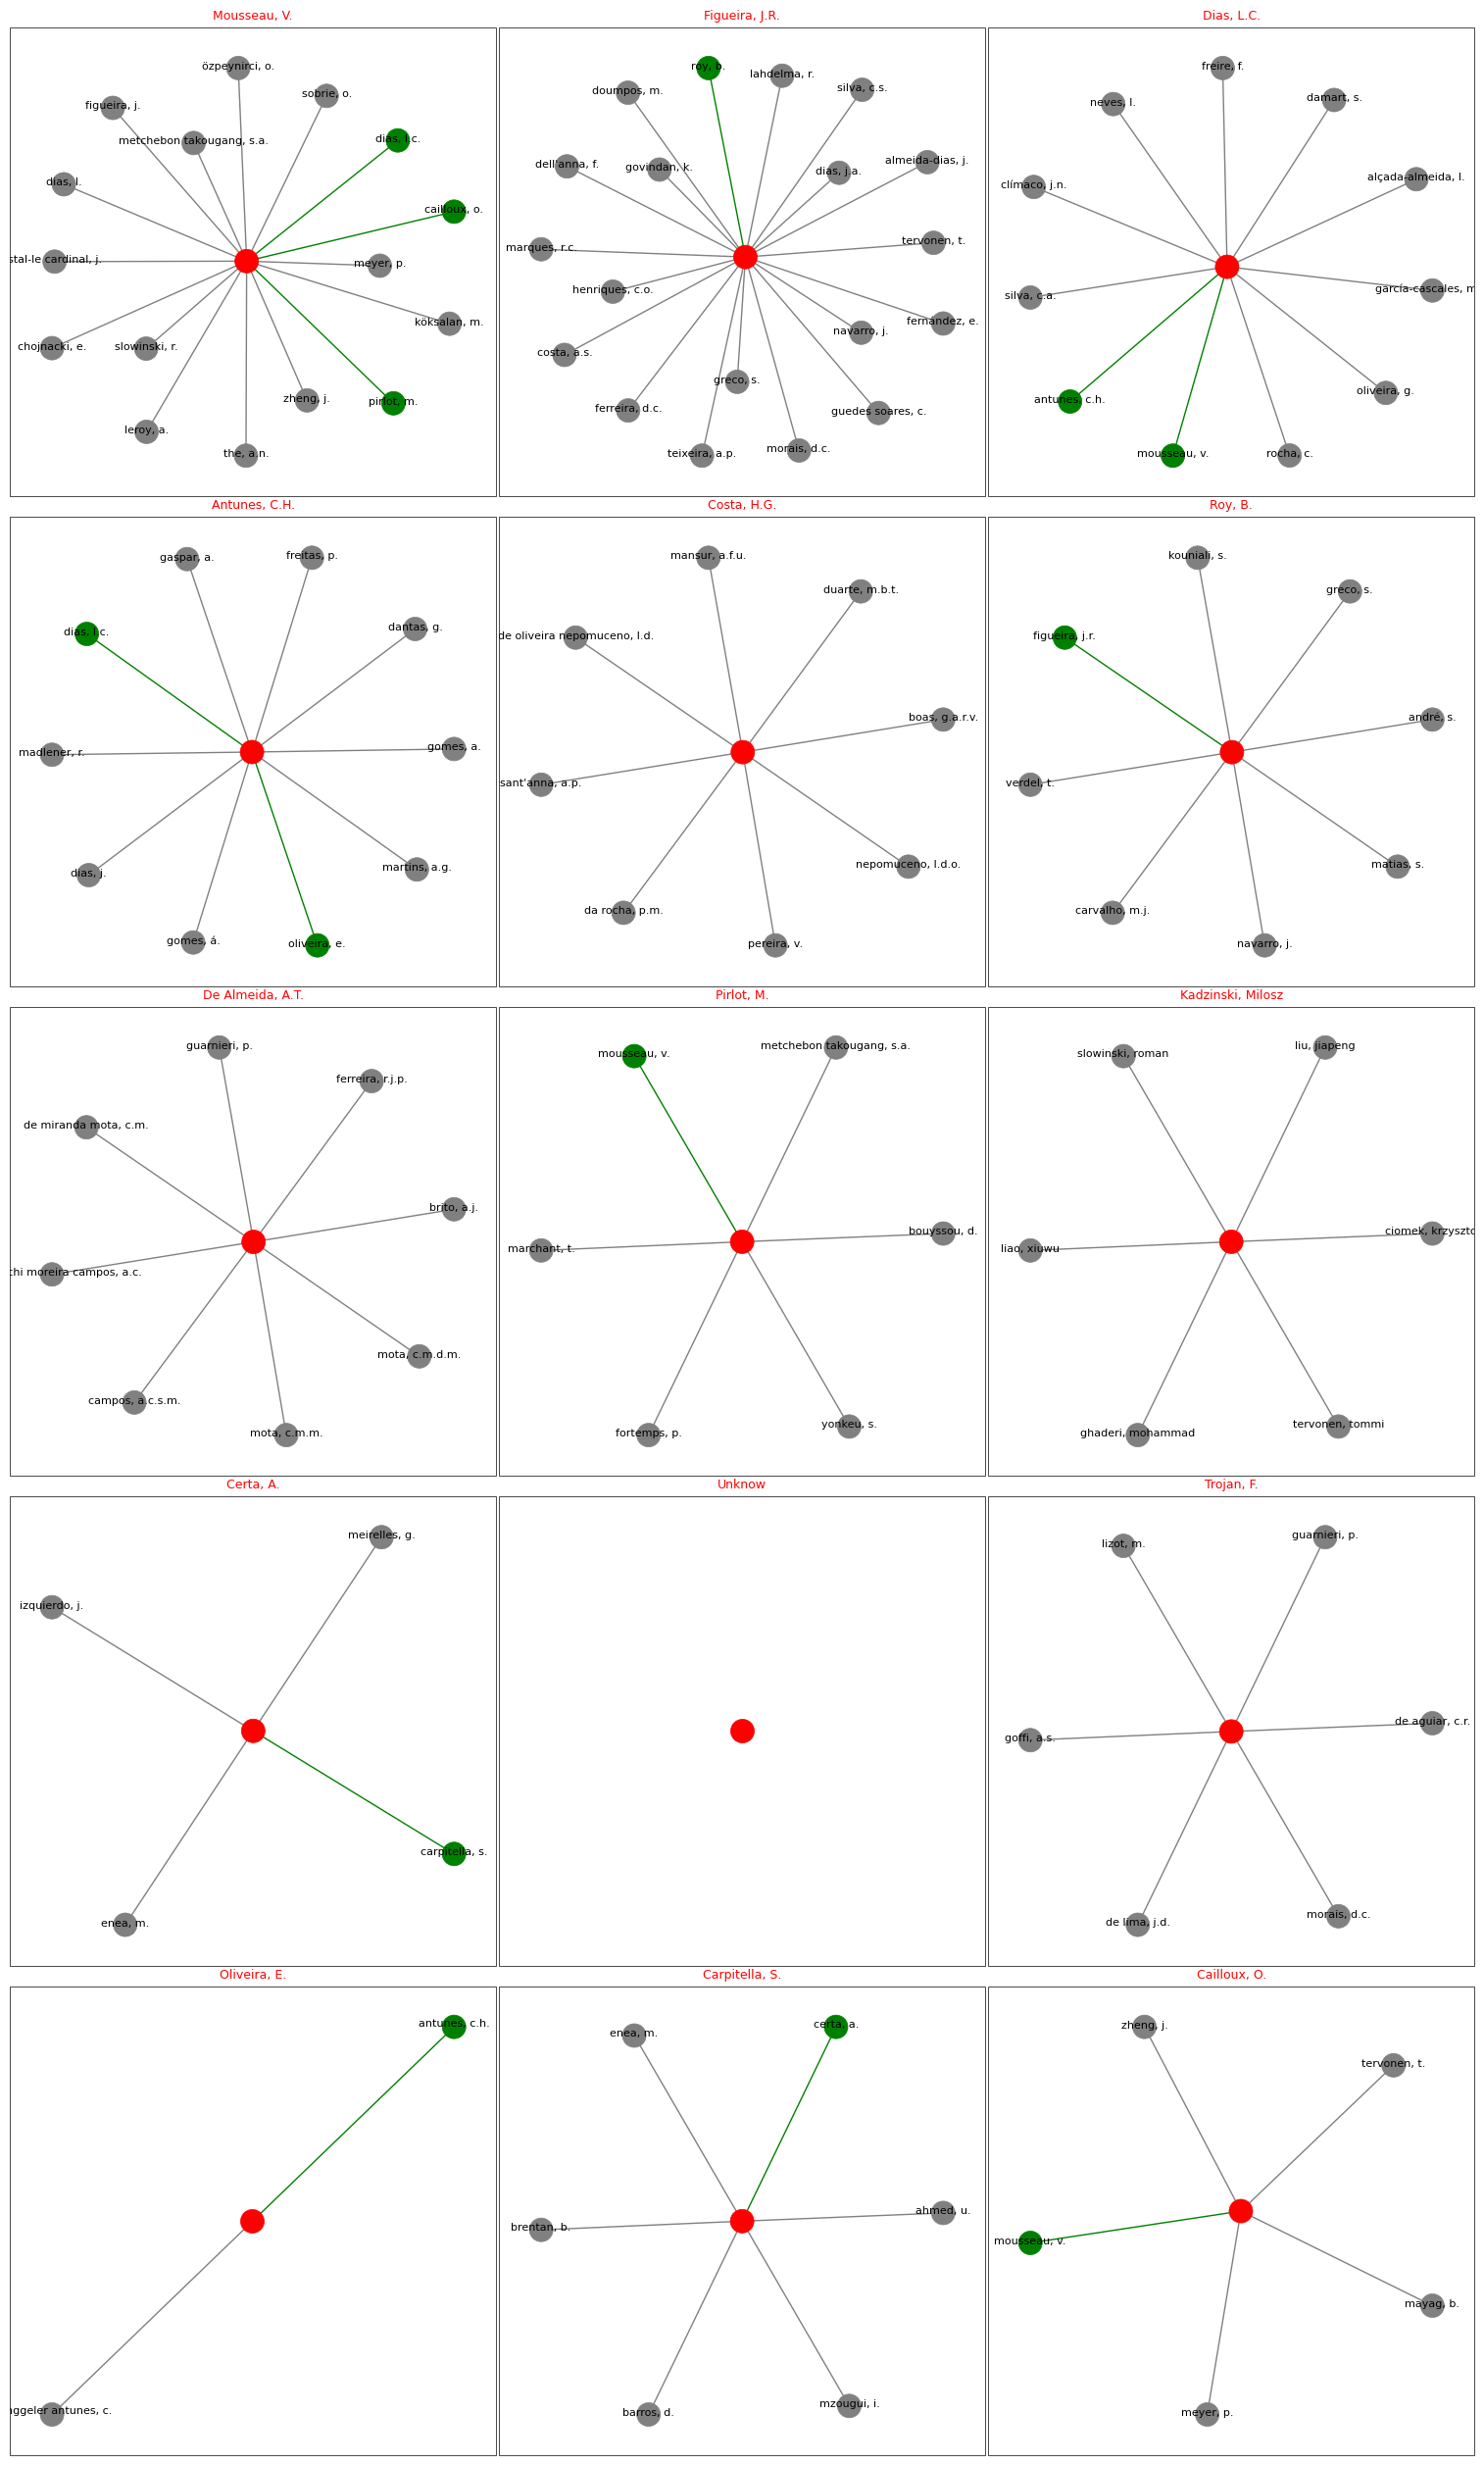

In [ ]:
# Arguments:
# entry      = 'aut', 'cout', 'inst', 'kwa', or 'kwp'.
# tgt        = List of specific names.
# topn       = Integer. Specifies the number of top authors to display based on their total contributions.
# rows       = Integer. Defines the number of rows in the subplot grid for the visual layout.
# cols       = Integer. Defines the number of columns in the subplot grid for the visual layout.
# wspace     = Float. Adjusts horizontal spacing between subplots.
# hspace     = Float. Adjusts vertical spacing between subplots.
# tspace     = Float. Sets additional vertical space between nodes and labels for better readability.
# node_size  = Integer. Controls the size of each node in the network graph.
# font_size  = Integer. Defines the font size for node labels.
# pad        = Float. Adjusts padding around the layout for a balanced appearance.
# nd_a       = Color string (e.g., '#FF0000'). Specifies the color for the primary node (main author).
# nd_b       = Color string (e.g., '#008000'). Specifies the color for secondary nodes (authors with significant links).
# nd_c       = Color string (e.g., '#808080'). Specifies the color for other nodes (authors with minor links).
# verbose    = Boolean. If True, prints details of each main node and its connections in the console; if False, suppresses this output.
bibfile.network_collab( entry     = 'aut',
                        tgt       = [],
                        topn      = 15,
                        rows      = 5,
                        cols      = 3,
                        wspace    = 0.2,
                        hspace    = 0.2,
                        tspace    = 0.01,
                        node_size = 300,
                        font_size = 8,
                        pad       = 0.2,
                        nd_a      = '#FF0000',
                        nd_b      = '#008000',
                        nd_c      = '#808080',
                        verbose   = False)

In [ ]:
print(bibfile.ask_gpt_ct)

[[['mousseau, v.'], ['cailloux, o.', 'chojnacki, e.', 'dias, l.', 'dias, l.c.', 'figueira, j.', 'köksalan, m.', 'leroy, a.', 'metchebon takougang, s.a.', 'meyer, p.', 'pirlot, m.', 'slowinski, r.', 'sobrie, o.', 'stal-le cardinal, j.', 'the, a.n.', 'zheng, j.', 'özpeynirci, o.']], [['figueira, j.r.'], ['almeida-dias, j.', 'costa, a.s.', "dell'anna, f.", 'dias, j.a.', 'doumpos, m.', 'fernández, e.', 'ferreira, d.c.', 'govindan, k.', 'greco, s.', 'guedes soares, c.', 'henriques, c.o.', 'lahdelma, r.', 'marques, r.c.', 'morais, d.c.', 'navarro, j.', 'roy, b.', 'silva, c.s.', 'teixeira, a.p.', 'tervonen, t.']], [['dias, l.c.'], ['alçada-almeida, l.', 'antunes, c.h.', 'clímaco, j.n.', 'damart, s.', 'freire, f.', 'garcía-cascales, m.s.', 'mousseau, v.', 'neves, l.', 'oliveira, g.', 'rocha, c.', 'silva, c.a.']], [['antunes, c.h.'], ['dantas, g.', 'dias, j.', 'dias, l.c.', 'freitas, p.', 'gaspar, a.', 'gomes, a.', 'gomes, á.', 'madlener, r.', 'martins, a.g.', 'oliveira, e.']], [['costa, h.g.']

In [ ]:
# Network - Citation Analisys Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_count   = Relationship between nodes that have been cited at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            local_nodes = True or False (True -> Only the blue will be displayed, False -> Red and Blue nodes will be displayed)
bibfile.network_adj_dir(view = 'notebook', min_count = 25, node_labels = True, node_size = 20, font_size = 10, local_nodes = False)

In [ ]:
# View Table
data_nad = bibfile.ask_gpt_nad
data_table.DataTable(data_nad, num_rows_per_page = 15)

,Paper,Cited Reference
0,261,r_2738
1,264,r_6583
2,264,r_6584
3,265,r_6584
4,266,r_6584
...,...,...
81,319,r_6584
82,320,r_6583
83,320,r_6584
84,321,r_6583


In [ ]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size;
bibfile.find_nodes_dir(view = 'notebook', article_ids = ['283'], ref_ids = [], node_size = 20, font_size = 10)

In [ ]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size
bibfile.find_nodes_dir(view = 'notebook', article_ids = [], ref_ids = ['r_2738'], node_size = 20, font_size = 10)

In [ ]:
# Network - Local Documents (Only Blue Nodes) Citation History. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_links   = Relationship between nodes that have connected at least x times;
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            chain       = A list of documents. It shows the documents and their citations;
#            path       =  Only relevant if 'chain' is not empty. True -> Show only the documents in 'chain'. False -> Show documents and connections.
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [], path = False, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
# View Table
data_hist = bibfile.ask_gpt_hist
data_table.DataTable(data_hist, num_rows_per_page = 15)

,Paper ID (Year),Reference ID (Year)
0,1 (2022),51 (2019)
1,1 (2022),59 (2019)
2,3 (2021),8 (2021)
3,3 (2021),45 (2019)
4,3 (2021),321 (2001)
...,...,...
300,42 (2020),44 (2019)
322,48 (2019),73 (2018)
360,133 (2015),156 (2014)
376,220 (2009),223 (2008)


In [ ]:
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [21, 208, 261], path = False, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
citations = bibfile.network_hist(view = 'notebook', min_links = 1, chain = [3, 8, 56, 84, 120, 248], path = True, node_size = 20, font_size = 10, node_labels = True)

In [ ]:
# Network - Analyze Hist. Citations
# Arguments: min_path_size = Minimum number of elements of a path.
hist_paths = bibfile.analyze_hist_citations(citations, min_path_size = 2)

Most Referenced Paper ID: 312 -> Cited 9 Times
Paper ID that Cites the Most: 261 -> Cites 22 Papers
Paper IDs of Longest Citation Path: [3, 8, 56, 84, 120, 248]


In [ ]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 5, node_labels = True, label_type = 'name', centrality = None)

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



In [ ]:
# View Table
data_adj = bibfile.ask_gpt_adj
data_table.DataTable(data_adj, num_rows_per_page = 15)

,Node 1 (Author),Node 2 (Author),Node 1 Cluster,Node 2 Cluster
0,ID: a_2,ID: a_556,12.0,12.0
1,ID: a_516,ID: a_47,14.0,14.0
2,ID: a_516,ID: a_278,14.0,14.0
3,ID: a_516,ID: a_328,14.0,14.0
4,ID: a_516,ID: a_335,14.0,14.0
...,...,...,...,...
323,ID: a_442,ID: a_473,12.0,12.0
324,ID: a_452,ID: a_493,1.0,1.0
325,ID: a_464,ID: a_472,11.0,11.0
326,ID: a_470,ID: a_503,1.0,1.0


In [ ]:
# Network - Highlight  Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view      = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            node_ids  = A list of IDs. Only meaningfull if label_type = 'id';
#            node_name = A list of Names. Only meaningfull iflabel_type = 'name';
#            node_only = True or False (True -> Only the Node will be Highlighted, False -> Node and its Connections will be Highlighted)
bibfile.find_nodes(node_ids = [], node_name = ['dias, l.c.'], node_only = False)

In [ ]:
# Network - Similarity Analysis using coupling or cocitation methods. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            sim_type    = 'coup', 'cocit' ('coup' -> Coupling Method, 'cocit' -> Cocitation Method)
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            cut_coup    = Cutoff value for Coupling Method. Only meaninfull if sim_type = 'coup';
#            cut_cocit   = Cutoff value for Cocitation Method. Only meaninfull if sim_type = 'cocit'
bibfile.network_sim(view = 'notebook', sim_type = 'cocit', node_size = 10, node_labels = True, cut_coup = 0.3, cut_cocit = 10)

In [ ]:
# Check Similarity Values
data_table.DataTable(bibfile.sim_table, num_rows_per_page = 15)

,Pair Node,Sim(cocit)
0,"(43,79)",12.0
1,"(172,178)",12.0
2,"(230,231)",22.0
3,"(261,263)",11.0
4,"(261,265)",11.0
5,"(261,268)",14.0
6,"(261,269)",17.0
7,"(261,273)",22.0
8,"(261,277)",20.0
9,"(261,286)",23.0


In [ ]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = [])

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



In [ ]:
# View Table
data_map = bibfile.ask_gpt_map
data_table.DataTable(data_map, num_rows_per_page = 15)

,Country 1,Country 2
0,Germany,Germany
1,Germany,Portugal
2,Germany,France
3,Chile,Chile
4,Chile,Brazil
...,...,...
124,France,Saudi Arabia
125,France,France
126,France,Turkey
127,Turkey,France


In [ ]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = False, country_lst = ['Mexico'])

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



# Artificial Intelligence Analysis
---
In this section, we will perform AI Analysis

In [ ]:
# NLP
# Arguments: corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.create_embeddings(stop_words = ['en'], rmv_custom_words = [], corpus_type = 'abs', model = 'allenai/scibert_scivocab_uncased')
emb = bibfile.embds

In [ ]:
# NLP #-1 refers to all outliers and should typically be ignored.
# Arguments: stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                              'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                              'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                              'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainianian;   'es' =  Spanish;  'sv' = Swedish
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            embeddings        = True or False. If True then word embeddings are used to create the topics
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.topics_creation(stop_words = ['en'], rmv_custom_words = [], embeddings = False, model = 'allenai/scibert_scivocab_uncased')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Topic  Count                                 Name  \
0     -1     93  -1_method_criteria_decision_electre   
1      0    153        0_decision_method_electre_tri   
2      1     37      1_decision_criteria_gis_electre   
3      2     22  2_energy_criteria_vehicles_decision   
4      3     17     3_risk_risks_pipeline_management   

                                      Representation  \
0  [method, criteria, decision, electre, tri, mod...   
1  [decision, method, electre, tri, model, criter...   
2  [decision, criteria, gis, electre, tri, area, ...   
3  [energy, criteria, vehicles, decision, analysi...   
4  [risk, risks, pipeline, management, gas, secti...   

                                 Representative_Docs  
0  [real life problems multi objective nature req...  
1  [finite alternatives sorting assignment proble...  
2  [weighted sum incorporated geographical inform...  
3  [paper proposes multi criteria decision approa...  
4  [companies today embraced concept risk managem..

In [ ]:
# Authors Production per Topic
production_topics = bibfile.topics_authors(topn = 15)
production_topics

,-1,0,1,2,3,Total
unknown,16,22,2,2,4,46
"mousseau, v.",1,18,0,1,3,23
"figueira, j.r.",7,8,1,2,0,18
"dias, l.c.",2,7,3,5,0,17
"antunes, c.h.",1,5,0,4,0,10
"costa, h.g.",5,4,0,0,0,9
"oliveira, e.",3,6,0,0,0,9
"roy, b.",1,5,1,0,1,8
"de almeida, a.t.",3,2,0,0,3,8
"pirlot, m.",2,5,1,0,0,8


In [ ]:
# NLP
# Each document Topic
topics = bibfile.topics

In [ ]:
# NLP
# Each document Probability to belong a Topic
probs = bibfile.probs

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_distribution(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_projection(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_heatmap(view = 'notebook')

In [ ]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_time(view = 'notebook')

In [ ]:
# NLP
bibfile.topics_representatives()

,Topic,Docs
0,-1.0,
1,0.0,252; 260; 12
2,1.0,141; 10; 185
3,2.0,224; 28; 71
4,3.0,112; 36; 2


In [ ]:
# NLP
similar_topics, similarity = bibfile.topic_model.find_topics('electre', top_n = 10)
for i in range(0, len(similar_topics)):
  print('Topic: ', similar_topics[i], 'Correlation: ', round(similarity[i], 3))

Topic:  2 Correlation:  0.167
Topic:  0 Correlation:  0.145
Topic:  -1 Correlation:  0.11
Topic:  1 Correlation:  0.107
Topic:  3 Correlation:  0.078


In [ ]:
# NLP
# Arguments: doc_id = Article ID. For the specified article, this function evaluates how each word in its abstract semantically aligns with all topics in the model.
df = bibfile.topics_words(doc_id = 42)
df

,Topic 0,Topic 1,Topic 2,Topic 3
This,0.141791,0.000000,0.000000,0.000000
paper,0.335558,0.126561,0.100748,0.000000
describes,0.488874,0.243369,0.100748,0.000000
ELECTRE,0.758254,0.469714,0.269622,0.111696
TRI,0.719960,0.469714,0.269622,0.111696
...,...,...,...,...
2020,0.368679,0.249591,0.000000,0.000000
Springer,0.169158,0.125513,0.000000,0.000000
Nature,0.000000,0.000000,0.000000,0.000000
Switzerland,0.000000,0.000000,0.000000,0.000000


In [ ]:
# NLP
bibfile.topic_model.save('my_topic_model')
#bibfile.topics_load_file('my_topic_model')

In [ ]:
# W2V
model, corpus, w_emb, vocab = bibfile.word_embeddings(stop_words        = ['en'],
                                                      lowercase         = True,
                                                      rmv_accents       = True,
                                                      rmv_special_chars = False,
                                                      rmv_numbers       = True,
                                                      rmv_custom_words  = [],
                                                      vector_size       = 100,
                                                      window            = 5,
                                                      min_count         = 1,
                                                      epochs            = 10)

In [ ]:
# W2V - Similarity
similarity = bibfile.word_embeddings_sim(model, word_1 = 'mcda', word_2 = 'risk')
similarity

0.9924341

In [ ]:
# W2V - Find Docs
results = bibfile.word_embeddings_find_doc(corpus, target_words = ['mcda', 'risk'])
results

[(37,
  'Ethereum smart contract system has seen a steady adoption as it continues to support tens of thousands of contracts. This feature has evolved to give a practical shape to the ideas leading up to fractional ownership transfer, using advanced smart contracts such as ERC-981. However, alongside its numerous benefits, various risks arise with the actual implementation of the ERC-981. This paper documents high-level processes and risk factors involved in the transfer-system, building a theoretical risk model based on Electre Tri-framework belonging to MCDA classification/sorting models. This model deals with detecting problems that are pre-defined on a central reference. The approach is illustrated through several stages: following comparison between the methods of risk analysis towards a risk assessment model, proposing recommendations and solutions. The framework was able to detect 18 major risks and bugs assigned to 6 categories. © 2020 ASTES Publishers. All rights reserved.'),


In [ ]:
# W2V - Operations
operations = bibfile.word_embeddings_operations(model, positive = ['mcda', 'group'], negative = ['risk'], topn = 10)
operations

[('aid', 0.9995383620262146),
 ('decision', 0.9995278716087341),
 ('multicriteria', 0.9994654059410095),
 ('criteria', 0.9994346499443054),
 ('making', 0.9994339942932129),
 ('multipath', 0.9994295239448547),
 ('mcdamulti', 0.9993982911109924),
 ('multicriterion', 0.9993323683738708),
 ('multi', 0.9992232918739319),
 ('multiple', 0.9991709589958191)]

In [ ]:
# W2V - Operations Plot.
bibfile.plot_word_embeddings(model,
                             view      = 'notebook',
                             positive  = [ ['mcda', 'group'], ['decision'],             ['group']],
                             negative  = [ ['risk'],          ['research', 'analysis'], []       ],
                             topn      = 5,
                             node_size = 10,
                             font_size = 14)

In [ ]:
# NLP - Abstractive Summarization
# Arguments: article_ids = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            model_name  = Available pre-trained models. Complete list is available at  https://huggingface.co/models?pipeline_tag=summarization&sort=downloads&search=pegasus
abs_summary = bibfile.summarize_abst_peg(article_ids = [2, 17, 37], model_name = 'google/pegasus-xsum')


Total Number of Valid Abstracts:  3



In [ ]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary, 150))

This paper proposes a structured analysis of uncertainty that uses a Monte Carlo and tools to generate a multidimensional risk classification with
global sensitivity for a natural gas pipeline system in the United States, Canada and the United Arab Emirates (UAE). This paper proposes a
multidimensional risk classification with global sensitivity analysis by making a structured analysis of uncertainty that uses a Monte Carlo
simulation and tools., followed by a review of the current state of the art in the field of multidimensional risk assessment for natural gas pipelines
and a discussion of the challenges posed by this approach.


In [ ]:
# NLP - Abstractive Summarization - chatGPT

# OBS 1: Requires the user to have an **API key** (https://platform.openai.com/account/api-keys))
# OBS 2: The limit of characters is 4097 per request

# Arguments: article_ids   = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            join_articles = If False then the abstracts will be analyzed separately. If True then the abstracts will be concate in a single text
#            api_key       = 'your_api_key_here'. Insert your personal API key (https://platform.openai.com/account/api-keys)
#            model         = Specifies the AI model used for text generation. The default value is "text-davinci-003"
#            query         = Ask chatGPT what you want to do with the abstracts. The default query is: 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words'
abs_summary_chat = bibfile.summarize_abst_chatgpt(article_ids = [2, 17, 37], join_articles = True, api_key = 'your_api_key_here', query = 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words', model = 'gpt-4')

Document ID2 Number of Characters: 2037
Document ID17 Number of Characters: 1398
Document ID37 Number of Characters: 987

Total Number of Valid Abstracts:  3.0



In [ ]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary_chat, 250))

Multidimensional risk assessment is a tool used by companies to evaluate multiple risk perspectives and to determine different mitigation actions. This paper proposes a multidimensional risk classification with global sensitivity analysis. The
analysis is done by making a structured analysis of uncertainty that uses a Monte Carlo Simulation and visualization tools. The sensitivity levels are statistically validated and defined for each section, thereby generating information on
modifications to the classification of levels of risk. The advantages of the proposals are that the proposed methodology enables decisions to be made on


In [ ]:
# NLP - Extractive Summarization
# Arguments: article_ids = A list of documents to perform an extractive summarization with the available abstracts. If the list is empty then all documents will be used
ext_summary = bibfile.summarize_ext_bert(article_ids = [2, 17, 37])


Total Number of Valid Abstracts:  3



Some weights of the model checkpoint at bert-large-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
# NLP - Check Extractive Summarization
print(textwrap.fill(ext_summary, 150))

Multidimensional risk assessment for natural gas pipelines has proved to be an efficient approach for companies to evaluate multiple risk perspectives
and to determine different mitigation actions. For example, 10% variation in the group of parameters related to the Critical Danger Radius (CDR), 6
out of 8 pipeline sections present high sensitivity levels; showing that their original risk classifications do not remain the same. Consequently,
managers should prioritize mitigation strategies to those sections with significant risk categories The advantages of our proposals are twofold. The
results show that the maximal approach of production safety accident criterion pays more attention to the risk density or risk consequences, which
follows the 'cask principle' and is much more useful controlling the risk when targeting the vulnerable links of engineering systems. This feature has
evolved to give a practical shape to the ideas leading up to fractional ownership transfer, using advanced 

# Correction and Data Manipulation
---
In this section, we will show how to Correct & Manipulate your Data

In [ ]:
# Filter the .bib File
# Arguments: document = A list of documents to retain. The other documents will be deleted
#            doc_type = A list of doc types. Check the 'report' to select the available types;
#            year_str = An integer the determines the starting year of collection -1 = All years;
#            year_end = An integer the determines the ending year of collection   -1 = All years;
#            sources  = A list of sources. Check the cell '# Check Sources IDs' to select the available types;
#            core     = A integer (-1, 1, 2, 3, 12, or 23) -1 = All sources, 1 = Bradford core 1, 2 = Bradford core 2, 3 = Bradford core 3, 12 = Bradford core 1 and 2, 23 = Bradford core 2 and 3;
#            country  = A list of countries. Check the cell '# Check Countries IDs' to select the available types;
#            language = A list of languages. Check the 'report' to select the available types
#            abstract = True or False. True removes UNKNOW values from the abstract.
bibfile.filter_bib(documents = [], doc_type = [], year_str = -1, year_end = -1, sources = [], core = -1, country = [], language = [], abstract = False)

In [ ]:
# Correct the .bib File
# Arguments: get         = A list of the current name(s);
#            replace_for = A string. This string will replace all matchs from the 'get' argument list
bibfile.merge_author(get = [], replace_for = 'name')
bibfile.merge_institution(get = [], replace_for = 'name')
bibfile.merge_country(get = [], replace_for = 'name')
bibfile.merge_language(get = [], replace_for = 'name')
bibfile.merge_source(get = [], replace_for = 'name')
bibfile.merge_reference(get = [], replace_for = 'name')

In [ ]:
# Work with modified .bib File

# 1) Input a .bib to instantiate a class => bibfile  = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)
# 2) Then made the modifications and save the data externally => bibfile.save_database(sep = '\t', name = 'data.csv')
# 3) To load the modified .bib file ( 'data.csv') => bibfile.load_database(name = 'data.csv')

# PS: Even with the saved 'data.csv', you always need to do step 1, so to be fast, have any small .bib file in hand.
# Then, you can go directly to step 3, and your saved .bib ('data.csv') will replace the small .bib